In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# PCells

A [PCell](https://en.wikipedia.org/wiki/PCell) (short for **parameterized
cell**) is a reusable cell whose geometry is generated by a Python function.
In kfactory, any function decorated with `@kf.cell` becomes a PCell.

Key benefits:

- **Automatic caching** — calling the same function with the same arguments
  returns the *identical* cell object (no duplicate shapes or redundant computation).
- **Auto-naming** — the cell name encodes its parameters (e.g.
  `wg_straight_W0p5_L10`), so GDS exports are always unambiguous.
- **Settings dict** — each cached cell records its construction parameters in
  `cell.settings`, enabling round-tripping and LVS annotation.

## API quick-reference

| Decorator | Cell type returned | Unit hint |
|---|---|---|
| `@kf.cell` | `KCell` (DBU integers) | DBU |
| `@kf.cell(output_type=kf.DKCell)` | `DKCell` (µm floats) | µm |
| `@kf.vcell` | `VKCell` (virtual; geometry is materialised in the layout only when the cell is inserted into a `KCell`) | any |
| `@pdk.cell` | `KCell` bound to a specific `KCLayout` | DBU |

## Setup

In [2]:
import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)


L = LAYER()
kf.kcl.infos = L

## 1 · Basic PCell — DBU API

Decorate a function that creates a `KCell` with `@kf.cell`.  All arguments must
be hashable (integers, floats, strings, `LayerInfo`) so the cache key can be
computed.

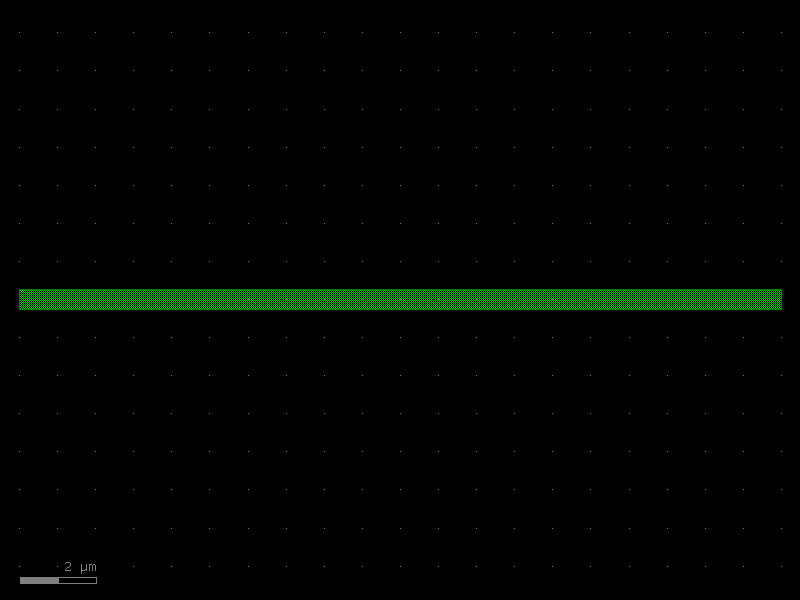

In [3]:
@kf.cell
def wg_straight(width: int, length: int) -> kf.KCell:
    """Straight waveguide (DBU coordinates).

    Args:
        width: Waveguide core width in DBU.
        length: Waveguide length in DBU.
    """
    c = kf.KCell()
    layer = kf.kcl.find_layer(L.WG)
    c.shapes(layer).insert(kf.kdb.Box(0, -width // 2, length, width // 2))
    c.add_port(
        port=kf.Port(
            name="o1",
            trans=kf.kdb.Trans(2, False, 0, 0),
            width=width,
            layer_info=L.WG,
        )
    )
    c.add_port(
        port=kf.Port(
            name="o2",
            trans=kf.kdb.Trans(0, False, length, 0),
            width=width,
            layer_info=L.WG,
        )
    )
    return c


# Construct with DBU arguments (1 nm = 1 DBU at default dbu=0.001 µm/DBU)
WG_WIDTH = kf.kcl.to_dbu(0.5)  # 500 DBU  (0.5 µm)
WG_LEN = kf.kcl.to_dbu(20.0)  # 20000 DBU (20 µm)

s = wg_straight(WG_WIDTH, WG_LEN)
s

### Automatic naming

The cell name is derived from the function name and its arguments.  Floats are
formatted with `p` in place of `.` to keep the name GDS-legal.

In [4]:
print(s.name)  # → wg_straight_W500_L20000
print(s.settings)  # → KCellSettings(width=500, length=20000)

wg_straight_W500_L20000
KCellSettings(width=500, length=20000)


### Caching

Calling `wg_straight` again with the *same* arguments returns the *exact same
object* — the body of the function is **not** executed a second time.

In [5]:
s2 = wg_straight(WG_WIDTH, WG_LEN)
s3 = wg_straight(WG_WIDTH, kf.kcl.to_dbu(30.0))  # different length → new cell

print("same args → same object:", s is s2)  # True
print("diff args → new object: ", s is s3)  # False

same args → same object: True
diff args → new object:  False


## 2 · µm API — `output_type=kf.DKCell`

For a µm-native interface, pass `output_type=kf.DKCell` to `@kf.cell`.  The
decorator wraps the returned `KCell` in a `DKCell` automatically — you can still
build geometry in DBU inside the function.

type: DKCell
name: wg_straight_um_W0p5_L20
settings: KCellSettings(width=0.5, length=20)


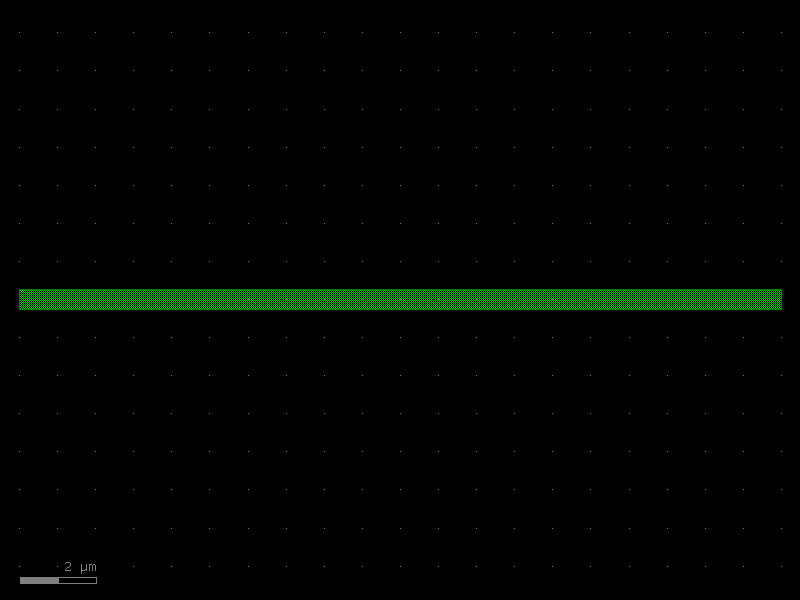

In [6]:
@kf.cell(output_type=kf.DKCell)
def wg_straight_um(width: float, length: float) -> kf.KCell:
    """Straight waveguide (µm API, DBU internals).

    Args:
        width: Waveguide core width in µm.
        length: Waveguide length in µm.
    """
    c = kf.KCell()
    layer = kf.kcl.find_layer(L.WG)
    w = kf.kcl.to_dbu(width)
    l_ = kf.kcl.to_dbu(length)
    c.shapes(layer).insert(kf.kdb.Box(0, -w // 2, l_, w // 2))
    c.add_port(
        port=kf.Port(
            name="o1",
            trans=kf.kdb.Trans(2, False, 0, 0),
            width=w,
            layer_info=L.WG,
        )
    )
    c.add_port(
        port=kf.Port(
            name="o2",
            trans=kf.kdb.Trans(0, False, l_, 0),
            width=w,
            layer_info=L.WG,
        )
    )
    return c


wg = wg_straight_um(0.5, 20.0)
print("type:", type(wg).__name__)  # DKCell
print("name:", wg.name)  # wg_straight_um_W0p5_L20
print("settings:", wg.settings)
wg

## 3 · Multi-layer PCell

PCells can draw on multiple layers.  Here a waveguide with a cladding layer
(slab) demonstrates layered geometry.

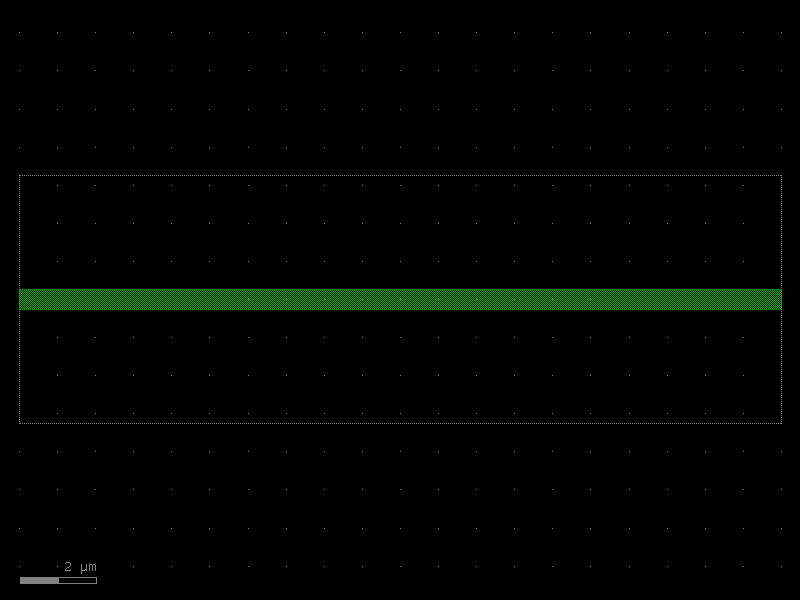

In [7]:
@kf.cell
def wg_clad(width: int, length: int, clad_width: int) -> kf.KCell:
    """Waveguide with slab cladding.

    Args:
        width: Core width in DBU.
        length: Waveguide length in DBU.
        clad_width: Extra cladding on each side in DBU.
    """
    c = kf.KCell()
    wg_layer = kf.kcl.find_layer(L.WG)
    clad_layer = kf.kcl.find_layer(L.WGCLAD)

    half_w = width // 2
    half_c = half_w + clad_width

    c.shapes(wg_layer).insert(kf.kdb.Box(0, -half_w, length, half_w))
    c.shapes(clad_layer).insert(kf.kdb.Box(0, -half_c, length, half_c))

    c.add_port(
        port=kf.Port(
            name="o1",
            trans=kf.kdb.Trans(2, False, 0, 0),
            width=width,
            layer_info=L.WG,
        )
    )
    c.add_port(
        port=kf.Port(
            name="o2",
            trans=kf.kdb.Trans(0, False, length, 0),
            width=width,
            layer_info=L.WG,
        )
    )
    return c


wg_c = wg_clad(
    width=kf.kcl.to_dbu(0.5),
    length=kf.kcl.to_dbu(20.0),
    clad_width=kf.kcl.to_dbu(3.0),
)
wg_c

## 4 · Composing PCells

PCells can reference other PCells via `cell.create_inst(other_cell)`.  The inner
cell is fetched from the cache (or created once and cached), so there is no
duplication even when many parent cells share the same child.

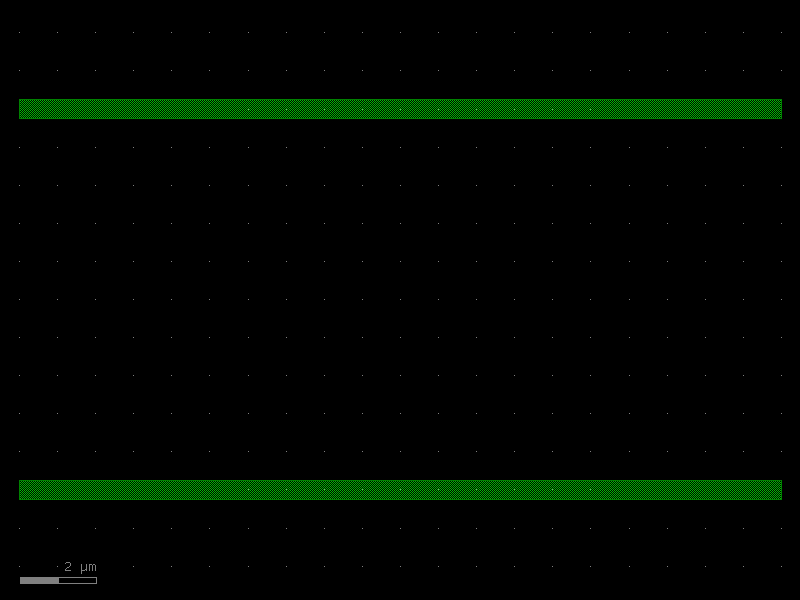

In [8]:
@kf.cell
def y_branch(width: int, length: int, arm_sep: int) -> kf.KCell:
    """Simplified Y-branch: one input, two parallel outputs.

    Args:
        width: Waveguide width in DBU.
        length: Arm length in DBU.
        arm_sep: Centre-to-centre separation of the two output arms in DBU.
    """
    c = kf.KCell()
    arm = wg_straight(width, length)  # fetched from cache

    inst_top = c.create_inst(arm)
    inst_bot = c.create_inst(arm)

    inst_top.transform(kf.kdb.Trans(0, False, 0, arm_sep // 2))
    inst_bot.transform(kf.kdb.Trans(0, False, 0, -(arm_sep // 2)))

    c.add_port(port=inst_top.ports["o2"], name="o_top")
    c.add_port(port=inst_bot.ports["o2"], name="o_bot")
    return c


yb = y_branch(WG_WIDTH, kf.kcl.to_dbu(20.0), kf.kcl.to_dbu(10.0))
yb

## 5 · Virtual cells — `@kf.vcell`

A `VKCell` (virtual cell) is built like a PCell but is **not** registered in the
KLayout cell database.  It is useful for intermediate helper geometry that never
needs to appear as a standalone cell in the GDS.

In [9]:
@kf.vcell
def marker_cross(size: int) -> kf.VKCell:
    """Alignment cross marker (virtual — not stored in the layout DB).

    Args:
        size: Half-width of each arm in DBU.
    """
    v = kf.VKCell()
    layer = kf.kcl.find_layer(L.WG)
    v.shapes(layer).insert(kf.kdb.Box(-size // 4, -size, size // 4, size))
    v.shapes(layer).insert(kf.kdb.Box(-size, -size // 4, size, size // 4))
    return v


m = marker_cross(kf.kcl.to_dbu(5.0))
print("VKCell type:", type(m).__name__)  # VKCell

VKCell type: VKCell


## 6 · Per-PDK cells — `@pdk.cell`

When building a PDK, each component should be created inside that PDK's
`KCLayout` instance rather than the global `kf.kcl`.  Use `@pdk.cell` instead
of `@kf.cell` so that layer indices are looked up from the correct layout.

name: pdk_straight_W0p45_L15
kcl:  DEMO_PDK


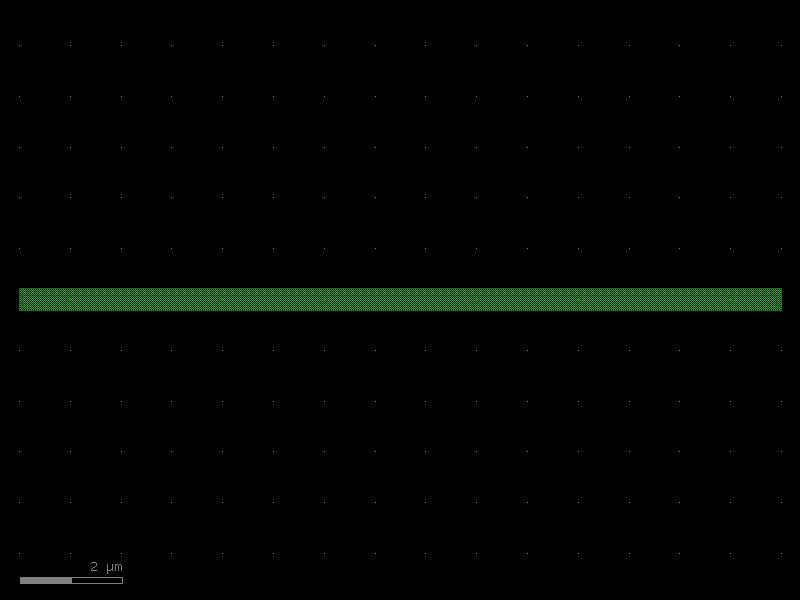

In [10]:
class PDK_LAYERS(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    SLAB: kf.kdb.LayerInfo = kf.kdb.LayerInfo(3, 0)


pdk = kf.KCLayout("DEMO_PDK", infos=PDK_LAYERS)


@pdk.cell
def pdk_straight(width: float, length: float) -> kf.KCell:
    """Straight waveguide inside DEMO_PDK layout.

    Args:
        width: Core width in µm.
        length: Waveguide length in µm.
    """
    c = pdk.kcell()
    layer = pdk.find_layer(PDK_LAYERS().WG)
    w = pdk.to_dbu(width)
    l_ = pdk.to_dbu(length)
    c.shapes(layer).insert(kf.kdb.Box(0, -w // 2, l_, w // 2))
    c.add_port(
        port=kf.Port(
            name="o1",
            trans=kf.kdb.Trans(2, False, 0, 0),
            width=w,
            layer_info=PDK_LAYERS().WG,
            kcl=pdk,
        )
    )
    c.add_port(
        port=kf.Port(
            name="o2",
            trans=kf.kdb.Trans(0, False, l_, 0),
            width=w,
            layer_info=PDK_LAYERS().WG,
            kcl=pdk,
        )
    )
    return c


ps = pdk_straight(0.45, 15.0)
print("name:", ps.name)  # pdk_straight_W0p45_L15
print("kcl: ", ps.kcl.name)  # DEMO_PDK
ps

## 7 · Decorator options

The `@kf.cell` decorator accepts several keyword arguments to control naming,
caching, and validation.

| Option | Default | Effect |
|---|---|---|
| `output_type` | `None` (→ `KCell`) | Wrap result in `DKCell` or a subclass |
| `basename` | function name | Override the name prefix |
| `set_name` | `True` | Auto-set cell name from params |
| `set_settings` | `True` | Populate `cell.settings` |
| `check_ports` | `True` | Warn on duplicate/unnamed ports |
| `snap_ports` | `True` | Snap port positions to grid |
| `cache` | shared per-layout dict | Custom cache (e.g. `{}` to disable) |

name:     WG_STRIP_W0p5_L10
settings: KCellSettings(width=0.5, length=10)


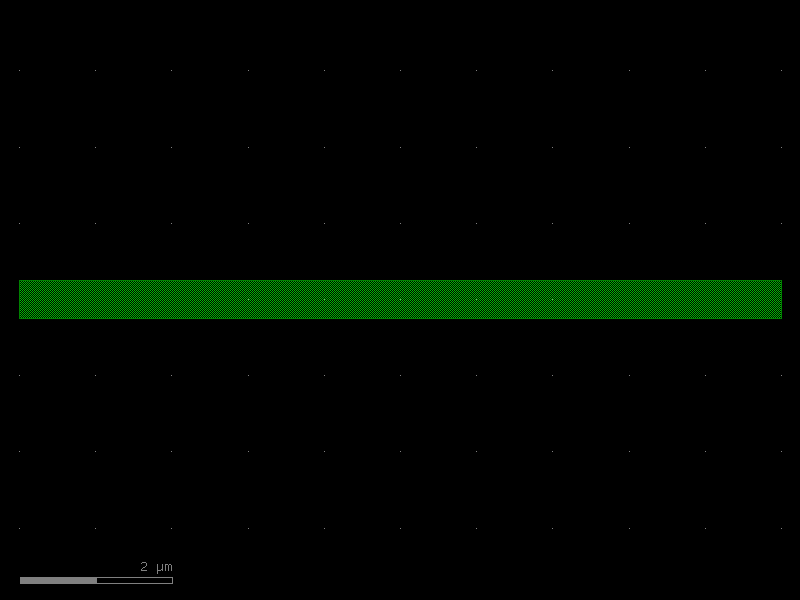

In [11]:
@kf.cell(basename="WG_STRIP", set_settings=True)
def strip_waveguide(width: float, length: float) -> kf.KCell:
    """Strip waveguide with custom basename."""
    c = kf.KCell()
    layer = kf.kcl.find_layer(L.WG)
    w = kf.kcl.to_dbu(width)
    l_ = kf.kcl.to_dbu(length)
    c.shapes(layer).insert(kf.kdb.Box(0, -w // 2, l_, w // 2))
    c.add_port(
        port=kf.Port(
            name="o1",
            trans=kf.kdb.Trans(2, False, 0, 0),
            width=w,
            layer_info=L.WG,
        )
    )
    c.add_port(
        port=kf.Port(
            name="o2",
            trans=kf.kdb.Trans(0, False, l_, 0),
            width=w,
            layer_info=L.WG,
        )
    )
    return c


sw = strip_waveguide(0.5, 10.0)
print("name:    ", sw.name)  # WG_STRIP_W0p5_L10
print("settings:", sw.settings)
sw

## Summary

| Task | API |
|---|---|
| DBU PCell | `@kf.cell` on a function returning `KCell` |
| µm PCell | `@kf.cell(output_type=kf.DKCell)` |
| Virtual cell | `@kf.vcell` on a function returning `VKCell` |
| PDK-scoped cell | `@pdk.cell` where `pdk` is a `KCLayout` |
| Custom name prefix | `@kf.cell(basename="MY_CELL")` |
| Disable name/settings | `set_name=False`, `set_settings=False` |

**Caching rules:** Two calls with equal arguments produce the same object — `a is b`
is `True`.  Arguments must be hashable (int, float, str, `LayerInfo`, frozen
containers).  Pass mutable state (like a `LayerEnclosure`) by name, not by value,
to avoid hash errors.

## See Also

| Topic | Where |
|-------|-------|
| Factory functions reference | [Components: Factories](factories/overview.py) |
| Virtual (non-physical) cells | [Components: Virtual Cells](virtual.py) |
| KCell / DKCell / VKCell basics | [Core Concepts: KCell](../../concepts/kcell.py) |
| DBU vs µm coordinate systems | [Core Concepts: DBU vs µm](../../concepts/dbu_vs_um.py) |
| Creating a full PDK | [PDK: Creating a PDK](../../pdk/creating_pdk.py) |